In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv

load_dotenv(override=True)

c:\Users\pumas\AppData\Local\Programs\Python\Python313\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


True

In [2]:
class State(TypedDict):
    user_review:str
    sentiment: Literal["Positive","Negative"]
    analysis: dict
    reply:str

In [3]:
class sentiment_schema(BaseModel):
    sentiment: Literal["Positive","Negative"] = Field(description="The sentiment of the user review")

class analysis_schema(BaseModel):
    issue_type: Literal["Bug","Service","Support","Pricing","Response Time","Other"] = Field(description="Type of the issue the user has faced")
    tone: Literal['Angry',"Frustated","Disappointed","Calm"] = Field(description="Tone of the user in the review")
    urgency: Literal["High","Medium","Low"] = Field(description="How urgent the issue is to be handled")

In [4]:
model = ChatGroq(model="openai/gpt-oss-20b")
sentiment_model = model.with_structured_output(sentiment_schema)
analysis_model = model.with_structured_output(analysis_schema)

In [5]:
def sentiment_analysis(old_state:State) -> Literal["Postive","Negative"]:
    prompt = "Do the proper sentiment analysis of the user review. Return either Postive or Negative\n"
    prompt =f"User Review:\n {old_state['user_review']}"

    respone = sentiment_model.invoke(prompt)

    return {"sentiment":respone.sentiment}

def negative_analysis(old_state:State):
    prompt = "Analyse the negative review of the user properly. Return issue_type, tone and urgency based on the review\n"
    prompt+= f"Review of the user:\n{old_state['user_review']}"

    response = analysis_model.invoke(prompt)

    return {"analysis":response.model_dump()}

def postive_reply(old_state:State) -> State:
    prompt = "The user gave positve review. Give a polite reply to the review and also mention to give a feedback on our website.\n"
    prompt+= f"User Review:\n {old_state['user_review']}"

    response = model.invoke(prompt)

    return {"reply":response.content}

def negative_reply(old_state:State) -> State:
    analysis=old_state['analysis']

    prompt = "The user gave negative review. Give a polite reply to the negative review based on the analysis we have done and shared below.\n"
    prompt+= f"""User Review:\n {old_state['user_review']}
                Issue type of the review:{analysis["issue_type"]}
                Tone of the review: {analysis["tone"]}
                Urgency of the review: {analysis["urgency"]}
             """

    response = model.invoke(prompt)

    return {"reply":response.content}


def reply_router(old_state:State) -> Literal["postive_reply","negative_analysis"]:
    if old_state["sentiment"] == "Positive":
        return "postive_reply"
    else:
        return "negative_analysis"

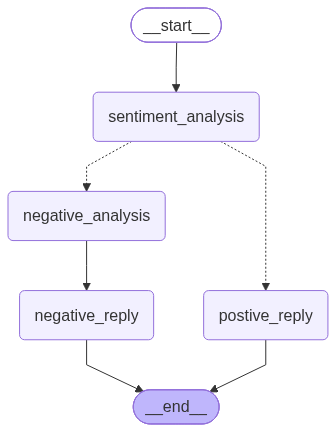

In [6]:
graph = StateGraph(State)

graph.add_node("sentiment_analysis",sentiment_analysis)
graph.add_node("negative_analysis",negative_analysis)
graph.add_node("postive_reply",postive_reply)
graph.add_node("negative_reply",negative_reply)

graph.add_edge(START,"sentiment_analysis")
graph.add_conditional_edges("sentiment_analysis",reply_router)
graph.add_edge("negative_analysis","negative_reply")
graph.add_edge("postive_reply",END)
graph.add_edge("negative_reply",END)

workflow = graph.compile()
workflow

In [8]:
input_data= {"user_review": "I am very disappointed with the product. The quality is poor, and the item arrived damaged. I expected much better service and would like this issue resolved as soon as possible."}
result = workflow.invoke(input_data)
result

{'user_review': 'I am very disappointed with the product. The quality is poor, and the item arrived damaged. I expected much better service and would like this issue resolved as soon as possible.',
 'sentiment': 'Negative',
 'analysis': {'issue_type': 'Bug', 'tone': 'Disappointed', 'urgency': 'High'},
 'reply': 'Hi there,\n\nI’m really sorry to hear about the condition of your order and the disappointment it has caused. Thank you for bringing this to our attention—your experience is far from what we aim to deliver, and we want to make it right as quickly as possible.\n\nCould you please share your order number and any photos of the damage? Once we have that information, we’ll arrange a replacement or refund immediately, and we’ll also investigate how the item was handled during shipping.\n\nWe truly value your business and appreciate the chance to correct this mistake. If you’d prefer to speak with a member of our support team directly, feel free to reply to this message or call us at\